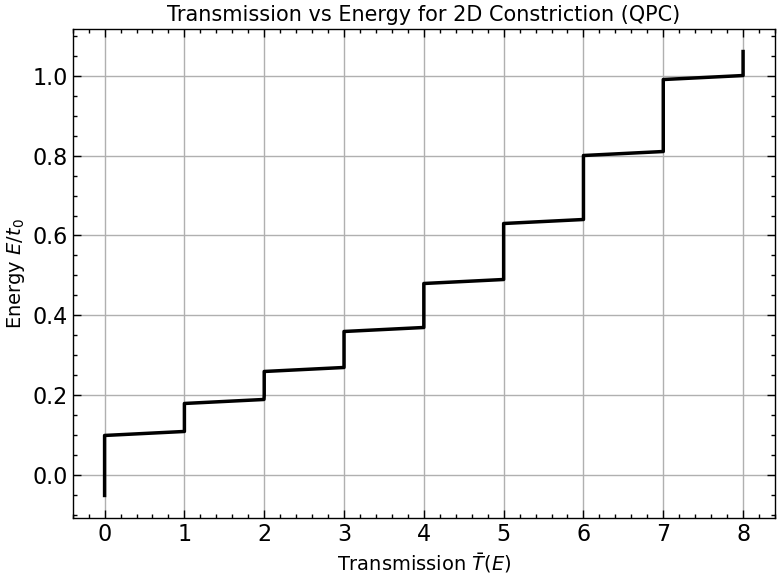

In [6]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use(['science' , 'notebook'])

# === Parameters ===
t0 = 1.0           # Hopping energy
a = 2.5e-9         # Lattice constant (not directly used, for units)
NW = 25            # Width of the 2D system
Np = 1             # Length in longitudinal direction (short constriction)
zplus = 1j * 1e-12
EE_list = np.arange(-0.05, 1.05 + 0.01, 0.01) * t0

q = 1.6e-19
hbar = 1.06e-34
qh = q / hbar
B = 0

# Construct alpha and beta matrices
al = 4 * t0
by = -t0 * np.eye(NW, k=1) + -t0 * np.eye(NW, k=-1)
alpha_base = np.eye(NW) * al + by
alpha_base += np.diag(np.arange(1, NW + 1) * 0.01)  # optional gradient
alpha_base += np.diag(np.concatenate([np.zeros(8), 0 * np.ones(9), np.zeros(8)]))  # potential bump

beta = np.diag(np.exp(1j * qh * B * a * a * np.arange(1, NW + 1))) * -t0

# Full Hamiltonian
H = np.kron(np.eye(Np), alpha_base)
if Np > 1:
    H += np.kron(np.eye(Np - 1, k=1), beta)
    H += np.kron(np.eye(Np - 1, k=-1), beta.T)

L = np.zeros((Np, Np))
R = np.zeros((Np, Np))
L[0, 0] = 1
R[-1, -1] = 1

Tcoh = []
E_vals = []

for EE in EE_list:
    ig0 = (EE + zplus) * np.eye(NW) - alpha_base
    gs1 = np.linalg.inv(ig0)
    change = 1
    while change > 1e-6:
        Gs = np.linalg.inv(ig0 - beta.T @ gs1 @ beta)
        change = np.sum(np.abs(Gs - gs1)) / np.sum(np.abs(gs1) + np.abs(Gs))
        gs1 = 0.5 * (Gs + gs1)
    Sigma1 = beta.T @ gs1 @ beta
    Sigma1 = np.kron(L, Sigma1)
    Gamma1 = 1j * (Sigma1 - Sigma1.conj().T)

    gs2 = np.linalg.inv(ig0)
    change = 1
    while change > 1e-6:
        Gs = np.linalg.inv(ig0 - beta @ gs2 @ beta.T)
        change = np.sum(np.abs(Gs - gs2)) / np.sum(np.abs(gs2) + np.abs(Gs))
        gs2 = 0.5 * (Gs + gs2)
    Sigma2 = beta @ gs2 @ beta.T
    Sigma2 = np.kron(R, Sigma2)
    Gamma2 = 1j * (Sigma2 - Sigma2.conj().T)

    G = np.linalg.inv((EE * np.eye(Np * NW)) - H - Sigma1 - Sigma2)
    T = np.real(np.trace(Gamma1 @ G @ Gamma2 @ G.conj().T))
    Tcoh.append(T)
    E_vals.append(EE / t0)

# === Plotting ===
plt.figure(figsize=(8, 6))
plt.plot(Tcoh, E_vals, 'k', linewidth=2.5)
plt.xlabel(r"Transmission $\bar{T}(E)$", fontsize=14)
plt.ylabel(r"Energy $E/t_0$", fontsize=14)
plt.title("Transmission vs Energy for 2D Constriction (QPC)", fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()


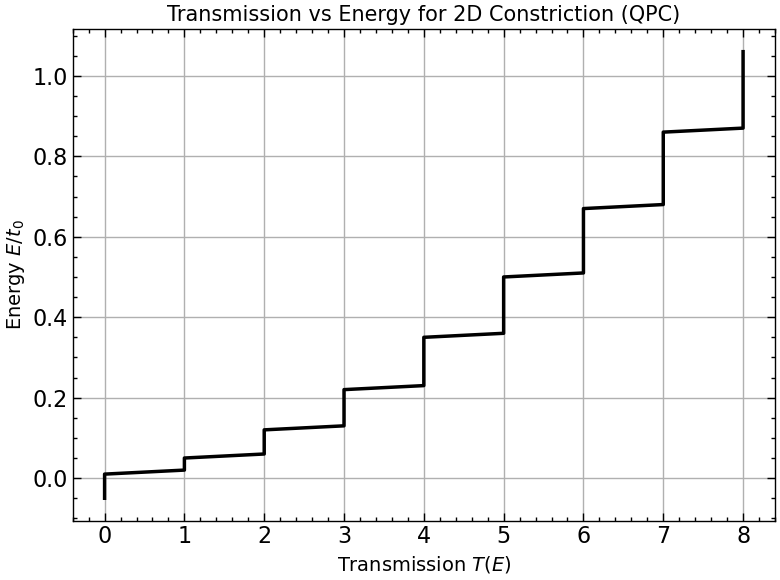

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use(['science' , 'notebook'])

# === Parameters ===
t0 = 1.0           # Hopping energy
a = 2.5e-9         # Lattice constant (not directly used, for units)
NW = 25            # Width of the 2D system
Np = 1             # Length in longitudinal direction (short constriction)
zplus = 1j * 1e-12
EE_list = np.arange(-0.05, 1.05 + 0.01, 0.01) * t0

# Constants for magnetic field (set B = 0 here)
q = 1.6e-19
hbar = 1.06e-34
qh = q / hbar
B = 0


# Construct alpha and beta matrices
al = 4 * t0
by = -t0 * np.eye(NW, k=1) + -t0 * np.eye(NW, k=-1)
alpha_base = np.eye(NW) * al + by
alpha_base += np.diag(np.arange(1, NW + 1) * 0)  # optional gradient
alpha_base += np.diag(np.concatenate([np.zeros(8), 0 * np.ones(9), np.zeros(8)]))  # potential bump

beta = np.diag(np.exp(1j * qh * B * a * a * np.arange(1, NW + 1))) * -t0

# Full Hamiltonian
H = np.kron(np.eye(Np), alpha_base)
if Np > 1:
    H += np.kron(np.eye(Np - 1, k=1), beta)
    H += np.kron(np.eye(Np - 1, k=-1), beta.T)

L = np.zeros((Np, Np))
R = np.zeros((Np, Np))
L[0, 0] = 1
R[-1, -1] = 1

Tcoh = []
E_vals = []

for EE in EE_list:
    ig0 = (EE + zplus) * np.eye(NW) - alpha_base
    gs1 = np.linalg.inv(ig0)
    change = 1
    while change > 1e-6:
        Gs = np.linalg.inv(ig0 - beta.T @ gs1 @ beta)
        change = np.sum(np.abs(Gs - gs1)) / np.sum(np.abs(gs1) + np.abs(Gs))
        gs1 = 0.5 * (Gs + gs1)
    Sigma1 = beta.T @ gs1 @ beta
    Sigma1 = np.kron(L, Sigma1)
    Gamma1 = 1j * (Sigma1 - Sigma1.conj().T)

    gs2 = np.linalg.inv(ig0)
    change = 1
    while change > 1e-6:
        Gs = np.linalg.inv(ig0 - beta @ gs2 @ beta.T)
        change = np.sum(np.abs(Gs - gs2)) / np.sum(np.abs(gs2) + np.abs(Gs))
        gs2 = 0.5 * (Gs + gs2)
    Sigma2 = beta @ gs2 @ beta.T
    Sigma2 = np.kron(R, Sigma2)
    Gamma2 = 1j * (Sigma2 - Sigma2.conj().T)

    G = np.linalg.inv((EE * np.eye(Np * NW)) - H - Sigma1 - Sigma2)
    T = np.real(np.trace(Gamma1 @ G @ Gamma2 @ G.conj().T))
    Tcoh.append(T)
    E_vals.append(EE / t0)

# === Plotting ===
plt.figure(figsize=(8, 6))
plt.plot(Tcoh, E_vals, 'k', linewidth=2.5)
plt.xlabel("Transmission $T(E)$", fontsize=14)
plt.ylabel("Energy $E/t_0$", fontsize=14)
plt.title("Transmission vs Energy for 2D Constriction (QPC)", fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()
